##### Setup

###### 1. Importações

In [1]:
import numpy as np
import matplotlib.pyplot as plt

###### 2. Função de desenho

In [2]:
def desenhar_figura(
    *,
    tracos=(),
    circunferencias=(),
    poligonos=(),
    pontos=None,
    titulo,
    arquivo,
):
    """Desenha primitivas definidas por vetores NumPy e salva a figura.

    Cada traço é (vértices Nx2, espessura); cada circunferência é
    (centro [x, y], raio, espessura). Polígonos são vetores Nx2.
    """
    figura, eixo = plt.subplots(figsize=(6, 6))
    angulos = np.linspace(0, 2 * np.pi, 361)
    circulo_unitario = np.column_stack((np.cos(angulos), np.sin(angulos)))

    for vertices, espessura in tracos:
        coordenadas = np.asarray(vertices, dtype=float)
        eixo.plot(coordenadas[:, 0], coordenadas[:, 1], color="black",
                  linewidth=espessura, solid_capstyle="round")

    for centro, raio, espessura in circunferencias:
        coordenadas = np.asarray(centro, dtype=float) + raio * circulo_unitario
        eixo.plot(coordenadas[:, 0], coordenadas[:, 1], color="black",
                  linewidth=espessura)

    for vertices in poligonos:
        coordenadas = np.asarray(vertices, dtype=float)
        eixo.fill(coordenadas[:, 0], coordenadas[:, 1], color="black")

    if pontos is not None:
        coordenadas = np.asarray(pontos, dtype=float)
        eixo.scatter(coordenadas[:, 0], coordenadas[:, 1],
                     color="black", s=45, zorder=3)

    eixo.set_aspect("equal", adjustable="box")
    eixo.margins(0.16)
    eixo.set_axisbelow(True)
    eixo.grid(True, color="#dddddd", linewidth=0.8)
    eixo.axhline(0, color="#888888", linewidth=1, zorder=0)
    eixo.axvline(0, color="#888888", linewidth=1, zorder=0)
    eixo.set_xlabel("x")
    eixo.set_ylabel("y")
    eixo.set_title(titulo)
    figura.tight_layout()
    figura.savefig(arquivo, dpi=160, bbox_inches="tight", facecolor="white")
    plt.show()

##### QUESTÃO1

###### 1.

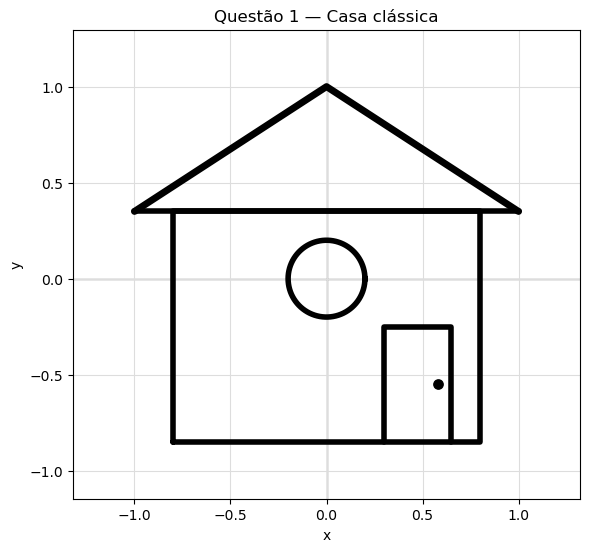

In [3]:
# Paredes, telhado e porta são retas; a janela é uma circunferência.
paredes = np.array([[-0.8, -0.85], [0.8, -0.85], [0.8, 0.35],
                    [-0.8, 0.35], [-0.8, -0.85]])
telhado = np.array([[-1.0, 0.35], [0.0, 1.0], [1.0, 0.35]])
beiral = np.array([[-1.0, 0.35], [1.0, 0.35]])
porta = np.array([[0.3, -0.85], [0.3, -0.25],
                  [0.65, -0.25], [0.65, -0.85]])

desenhar_figura(
    tracos=[(paredes, 4), (telhado, 5), (beiral, 4), (porta, 4)],
    circunferencias=[(np.array([0.0, 0.0]), 0.2, 4)],
    pontos=np.array([[0.58, -0.55]]),
    titulo="Questão 1 — Casa clássica",
    arquivo="lista2_questao1_casa.png",
)

##### QUESTÃO2 

###### 1.

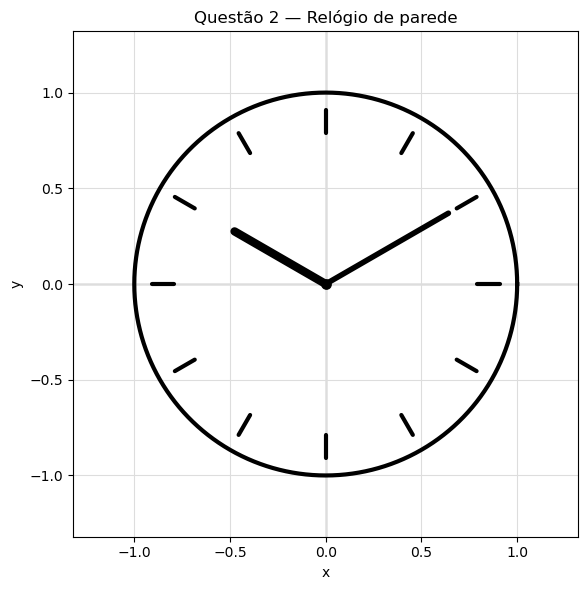

In [4]:
# Doze direções igualmente espaçadas definem os marcadores.
angulos = np.pi / 2 - np.arange(12) * np.pi / 6
direcoes = np.column_stack((np.cos(angulos), np.sin(angulos)))
marcadores = [(np.vstack((0.79 * direcao, 0.91 * direcao)), 3)
               for direcao in direcoes]

# Ambos os ponteiros são inclinados, como pede o enunciado.
ponteiro_horas = 0.55 * np.array([np.cos(5 * np.pi / 6),
                                  np.sin(5 * np.pi / 6)])
ponteiro_minutos = 0.74 * np.array([np.cos(np.pi / 6),
                                    np.sin(np.pi / 6)])
ponteiros = [(np.vstack((np.zeros(2), ponteiro_horas)), 6),
             (np.vstack((np.zeros(2), ponteiro_minutos)), 4)]

desenhar_figura(
    tracos=marcadores + ponteiros,
    circunferencias=[(np.zeros(2), 1.0, 3)],
    pontos=np.array([[0.0, 0.0]]),
    titulo="Questão 2 — Relógio de parede",
    arquivo="lista2_questao2_relogio.png",
)

##### QUESTÃO3 

###### 1.

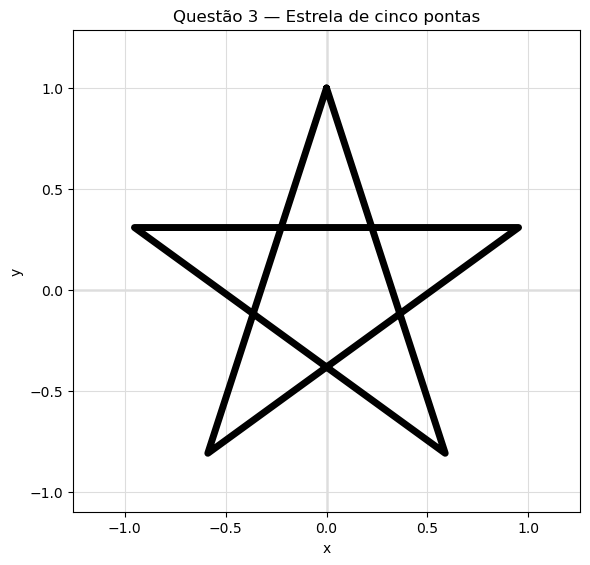

In [5]:
# Vértices na circunferência; a ordem 0, 2, 4, 1, 3 fecha a estrela.
angulos = np.pi / 2 + 2 * np.pi * np.arange(5) / 5
vertices = np.column_stack((np.cos(angulos), np.sin(angulos)))
estrela = vertices[[0, 2, 4, 1, 3, 0]]

desenhar_figura(
    tracos=[(estrela, 5)],
    titulo="Questão 3 — Estrela de cinco pontas",
    arquivo="lista2_questao3_estrela.png",
)

##### QUESTÃO4 

###### 1.

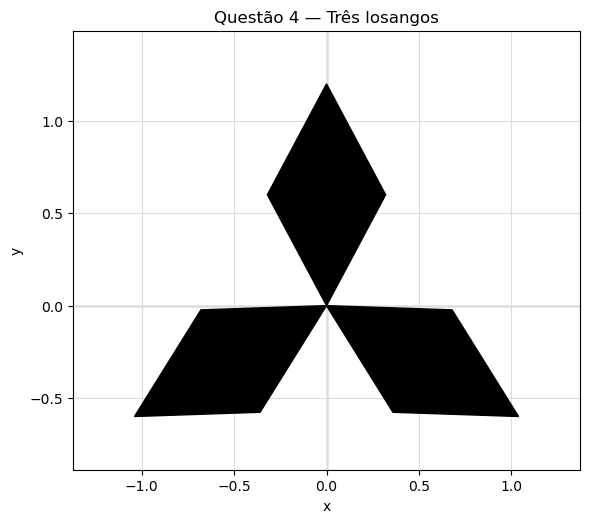

In [6]:
# Um losango e duas rotações de 120° formam as três peças.
losango = np.array([[0.0, 0.0], [-0.32, 0.60], [0.0, 1.20],
                    [0.32, 0.60]])
poligonos = []
for angulo in (0, 2 * np.pi / 3, -2 * np.pi / 3):
    rotacao = np.array([[np.cos(angulo), -np.sin(angulo)],
                        [np.sin(angulo), np.cos(angulo)]])
    poligonos.append(losango @ rotacao.T)

desenhar_figura(
    poligonos=poligonos,
    titulo="Questão 4 — Três losangos",
    arquivo="lista2_questao4_losangos.png",
)

##### QUESTÃO5 

###### 1.

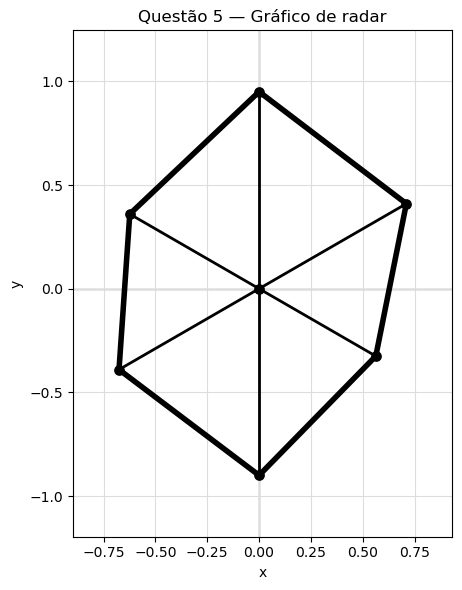

In [7]:
# Cada valor determina a distância de um vértice ao centro.
valores = np.array([0.95, 0.82, 0.65, 0.90, 0.78, 0.72])
angulos = np.pi / 2 - 2 * np.pi * np.arange(6) / 6
direcoes = np.column_stack((np.cos(angulos), np.sin(angulos)))
vertices = valores[:, None] * direcoes
raios = [(np.vstack((np.zeros(2), vertice)), 2) for vertice in vertices]
contorno = np.vstack((vertices, vertices[0]))

desenhar_figura(
    tracos=raios + [(contorno, 4)],
    pontos=np.vstack((vertices, np.zeros(2))),
    titulo="Questão 5 — Gráfico de radar",
    arquivo="lista2_questao5_radar.png",
)